# BrepGen: A B-rep Generative Diffusion Model with Structured Latent Geometry

This notebook provides a visual walkthrough of how **BrepGen** (SIGGRAPH 2024) generates 3D CAD Boundary Representation (B-rep) models directly from scratch.

Unlike command-sequence approaches such as **DeepCAD** (which generate construction history: 2D sketches + extrusions + Booleans), **BrepGen** directly synthesizes the **Boundary Representation (B-rep)** consisting of 3D geometric surfaces, trimming curve edges, and topological vertices.

<img src="./images/teaser_brepgen.jpg" width="1000" height=auto>

---
### Key Paradigm Comparison: DeepCAD vs. BrepGen

| Dimension | DeepCAD (ICCV 2021) | BrepGen (SIGGRAPH 2024) |
| :--- | :--- | :--- |
| **CAD Representation** | Construction sequence: Sketch-and-extrude history | Direct Boundary Representation (B-rep): Faces, Edges, Vertices |
| **Model Type** | Transformer Autoencoder + Latent GAN (WGAN-GP) | Hierarchical Latent Diffusion Models (LDM) + Schedulers |
| **Geometry Representation** | Discrete curve commands + numerical parameters | Continuous B-spline / NURBS surfaces & 3D space curves |
| **Topology** | Implicitly derived by CSG Boolean operations | Graph incidence matrices ($A^{FE}, A^{EV}$) + Joint Optimization |
| **Geometric Expressiveness** | Limited to 2.5D extrusion solids with simple loops | Full 3D freeform B-rep solids with complex curved topologies |
| **Conditioning** | Unconditional | Supports both unconditional and Classifier-Free Class Conditioning |


In [2]:
import os
import sys
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trimesh
import trimesh.viewer
from IPython.display import display, HTML
import build123d as bd

# Ensure project source directory is in sys.path
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'src'))
sys.path.append(os.path.join(os.getcwd(), 'src', 'eispdiff', 'cad_gen', 'brepgen'))


# Import shared CAD visualization utilities (exact same visualizer as DeepCAD)
from eispdiff.cad_gen.utils import solid_to_mesh, render_3d_mesh_jupyter

# Import BrepGen modular pipeline utilities and original author functions
from custom_utils import (
    text2int,
    int2text,
    init_schedulers,
    load_brepgen_models,
    step1_generate_surface_positions,
    step1_generate_surface_latents,
    step2_generate_edge_positions,
    step2_generate_edge_latents,
    step3_reconstruct_cad_solid,
    plot_3d_bounding_boxes,
    plot_surface_patches_pointcloud,
    generate_brep_cad_model,
)

from .utils import (
    construct_brep,
    detect_shared_vertex,
    detect_shared_edge,
    joint_optimize,
    plot_3d_bbox,
)

import torch
TORCH_SEED = 42
torch.manual_seed(TORCH_SEED)
np.random.seed(TORCH_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


if os.path.exists('../checkpoints/brepgen'):
    CHECKPOINT_BASE_DIR = '../checkpoints/brepgen'
elif os.path.exists('checkpoints/brepgen'):
    CHECKPOINT_BASE_DIR = 'checkpoints/brepgen'
else:
    CHECKPOINT_BASE_DIR = '../checkpoints/brepgen'


ModuleNotFoundError: No module named 'tqdm'

---
## Structured Latent Geometry Representation

A CAD B-rep is composed of a hierarchical set of **Faces**, **Edges**, and **Vertices**:
- **Faces**: Bounded parametric surfaces $S(u, v) \in \mathbb{R}^3$.
- **Edges**: 3D parametric curves $C(t) \in \mathbb{R}^3$ that trim face boundaries.
- **Vertices**: Discrete 3D points at curve endpoints.

BrepGen represents these components using **Structured Latent Geometry**:

```
      [ Surface Bounding Boxes B^F ]  ∈ ℝ^(N_F × 6)      <- Step 1-1 (PNDM + DDPM)
                     ↓
      [ Surface Continuous Latents z^F ] ∈ ℝ^(N_F × 48)  <- Step 1-3 (PNDM)
                     ↓
      [ Edge Bounding Boxes B^E ]    ∈ ℝ^(N_F × N_E × 6) <- Step 2-1 (PNDM + DDPM)
                     ↓
      [ Edge Latents z^E & Vertices v ] ∈ ℝ^(N_F × N_E × 18) <- Step 2-3 (PNDM)
                     ↓
      [ VAE Decoders + Post-Processing Reconstruction ]  <- Step 3 (Topology Recovery)
```

1. **Surface Geometry (Surface VAE)**:
   - Each surface patch is represented by a regular $32 \times 32$ point grid in normalized coordinates $[-1, 1]^3$.
   - A 2D KL-Autoencoder encodes each surface into a compact latent vector of shape $16 \times 3 = \mathbf{48}\text{-D}$.
2. **Edge Geometry (Edge 1D VAE)**:
   - Each edge curve is sampled with $32$ points in normalized coordinates $[-1, 1]^3$.
   - A 1D convolutional KL-Autoencoder encodes each edge into a $\mathbf{12}\text{-D}$ latent ($4 	imes 3$).
3. **Bounding Boxes (Spatial Anchors)**:
   - Surface bounding boxes $B^F = [x_{\min}, y_{\min}, z_{\min}, x_{\max}, y_{\max}, z_{\max}] \in \mathbb{R}^6$ anchor face locations.
   - Edge bounding boxes $B^E \in \mathbb{R}^6$ anchor edge locations relative to their parent face.
4. **Vertex Offsets**:
   - The remaining $6\text{-D}$ of the $18\text{-D}$ edge vector predict the start and end vertex coordinates $(v_{\text{start}}, v_{\text{end}})$ of each edge.


---
## Generating DeepCAD Models

In this section, we walk through the generation of CAD models trained on the **DeepCAD dataset**.
The generation is unconditional (`use_cf = False`) with default hyperparameters:
- `num_surfaces`: $30$ initial surface bounding boxes
- `num_edges`: $30$ edge candidates per face
- `z_threshold`: $0.2$ for edge latent matching
- `bbox_threshold`: $0.08$ for bounding box deduplication


In [2]:
# DeepCAD Model Checkpoint Paths
deepcad_dir = os.path.join(CHECKPOINT_BASE_DIR, 'deepcad') if os.path.exists(os.path.join(CHECKPOINT_BASE_DIR, 'deepcad')) else CHECKPOINT_BASE_DIR
deepcad_weights = {
    'surfpos_weight': os.path.join(deepcad_dir, 'deepcad_ldm_surfpos.pt'),
    'surfz_weight':   os.path.join(deepcad_dir, 'deepcad_ldm_surfz.pt'),
    'edgepos_weight': os.path.join(deepcad_dir, 'deepcad_ldm_edgepos.pt'),
    'edgez_weight':   os.path.join(deepcad_dir, 'deepcad_ldm_edgez.pt'),
    'surfvae_weight': os.path.join(deepcad_dir, 'deepcad_vae_surf.pt'),
    'edgevae_weight': os.path.join(deepcad_dir, 'deepcad_vae_edge.pt'),
}
# Initialize schedulers
pndm_scheduler, ddpm_scheduler = init_schedulers()
# Check if model checkpoints are present
deepcad_ready = all(os.path.exists(p) for p in deepcad_weights.values())
if not deepcad_ready:
    raise ValueError(f"Could not find checkpoints at {CHECKPOINT_BASE_DIR}")
deepcad_models = load_brepgen_models(deepcad_weights, use_cf=False, device=device)
print("Successfully loaded all DeepCAD neural models onto", device)


/home/mnb/Documents/ETH/Code/Master-Thesis/src/eispdiff/cad_gen/brepgen/network.py:1078: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.net = nn.TransformerEncoder(layer, 12, nn.LayerNorm(self.embed_dim))
/home/mnb/Documents/ETH/Code/Master-Thesis/src/eispdiff/cad_gen/brepgen/network.py:1140: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.net = nn.TransformerEncoder(layer, 12, nn.LayerNorm(self.embed_dim))
/home/mnb/Documents/ETH/Code/Master-Thesis/src/eispdiff/cad_gen/brepgen/network.py:1214: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.net = nn.TransformerEncoder(layer, 12, nn.LayerNorm(self.embed_dim))
/home/mnb/Documents/ETH/Code/Master-Thesis/src/eispdiff/cad_gen/brepgen/network.py:1300: UserWarning: enable_nested_tensor is True, but self.u

Successfully loaded all DeepCAD neural models onto cuda


---
### Step 1: Surface Generation

The generation begins at the top of the hierarchy:
1. **Step 1-1 (Surface Position Diffusion)**:
   - Sample Gaussian noise $B^F \sim \mathcal{N}(0, I) \in \mathbb{R}^{B 	imes 30 	imes 6}$.
   - Denoise using `SurfPosNet` with PNDM (158 steps) followed by fine DDPM (250 steps).
   - For unconditional ABC/DeepCAD models, duplicate surfaces (`late increase`) to allow fine surface coverage.
2. **Step 1-2 (Deduplication)**:
   - Filter out duplicate/overlapping bounding boxes using Chebyshev distance ($L_\infty < \tau_{\text{bbox}} = 0.08$).
3. **Step 1-3 (Surface Continuous Latent Diffusion)**:
   - Sample Gaussian noise $z^F \sim \mathcal{N}(0, I) \in \mathbb{R}^{B 	imes N_F 	imes 48}$.
   - Denoise using `SurfZNet` conditioned on the deduplicated bounding boxes and valid face mask.


In [3]:
batch_size = 4
num_surfaces = 30

# 1-1 & 1-2: Generate deduplicated surface bounding boxes
surfPos, surfMask, cur_num_surfaces = step1_generate_surface_positions(
    deepcad_models, 
    pndm_scheduler, 
    ddpm_scheduler,
    batch_size=batch_size, 
    num_surfaces=num_surfaces,
    use_cf=False, 
    bbox_threshold=0.08, 
    device=device
)
# 1-3: Generate surface latents conditioned on positions
surfZ = step1_generate_surface_latents(
    deepcad_models, 
    pndm_scheduler, 
    surfPos, 
    surfMask,
    batch_size=batch_size, 
    num_surfaces=cur_num_surfaces,
    use_cf=False, 
    device=device
)

print(f"Surface Positions Shape: {tuple(surfPos.shape)}")
print(f"Surface Mask Shape:      {tuple(surfMask.shape)}")
print(f"Surface Latents z Shape: {tuple(surfZ.shape)}")

print("\nValid surfaces counts:")
for i in range(batch_size):
    valid_surfs = (~surfMask[i]).sum().item()
    print(f"   Sample #{i}: {valid_surfs}/{cur_num_surfaces}")


Step 1-3: Surface Latent z (PNDM): 100%|██████████| 209/209 [00:01<00:00, 128.09it/s]

Surface Positions Shape: (4, 60, 6)
Surface Mask Shape:      (4, 60)
Surface Latents z Shape: (4, 60, 48)

Valid surfaces counts:
   Sample #0: 19/60
   Sample #1: 18/60
   Sample #2: 24/60
   Sample #3: 11/60


### Visualizing Surface Bounding Boxes and Latent Distributions
Let's inspect the spatial distribution of the generated surface bounding boxes in 3D and analyze the histogram of the 48-D latent geometry vectors $z_F$:


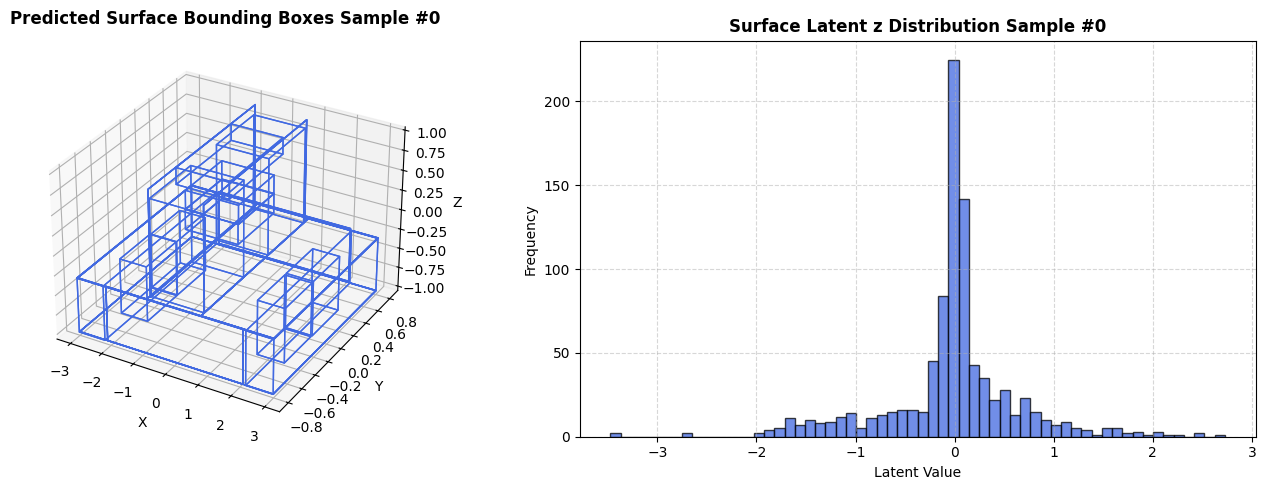

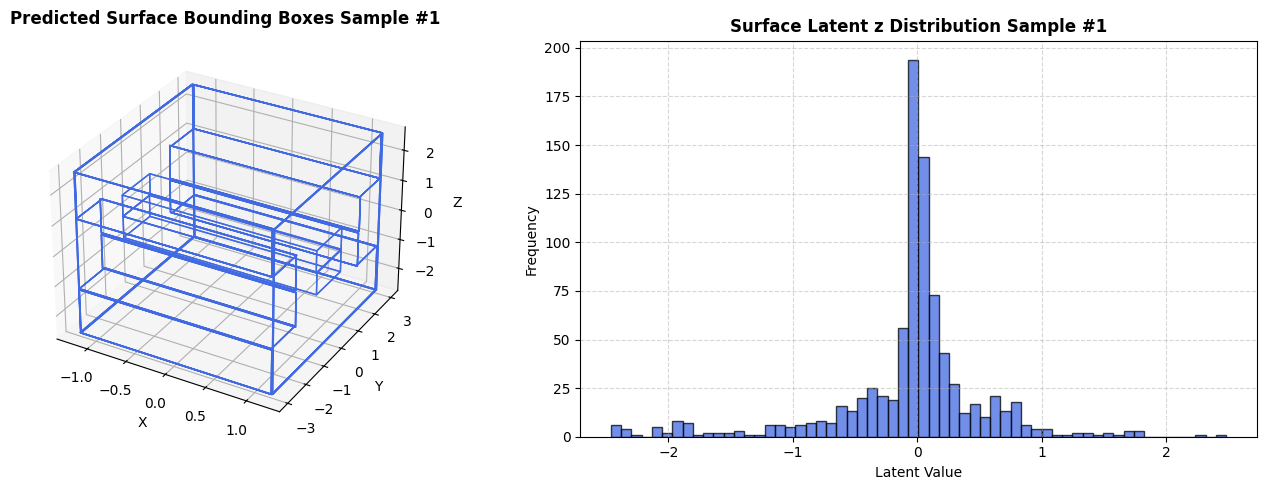

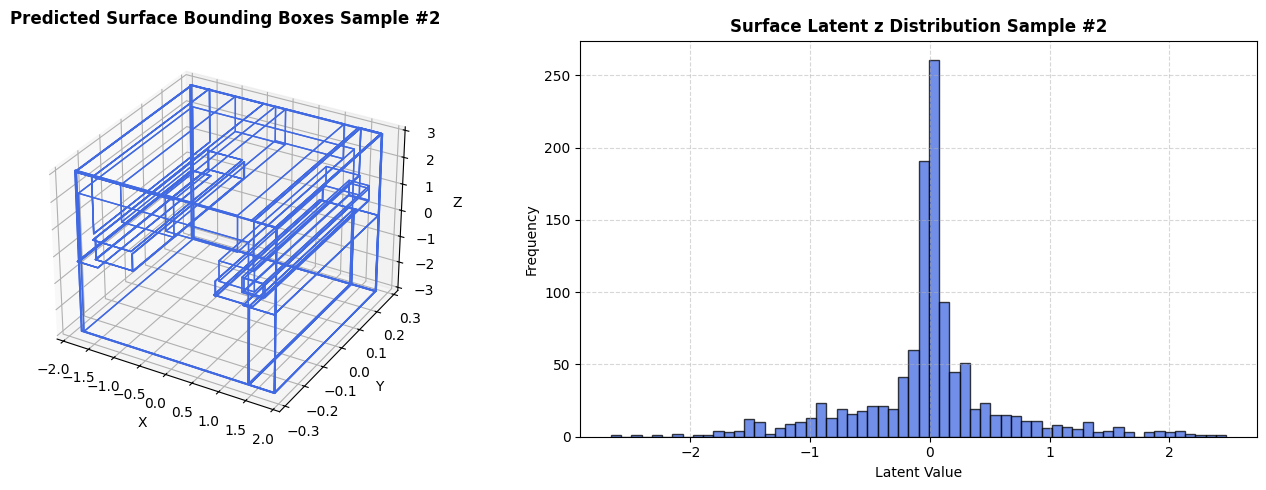

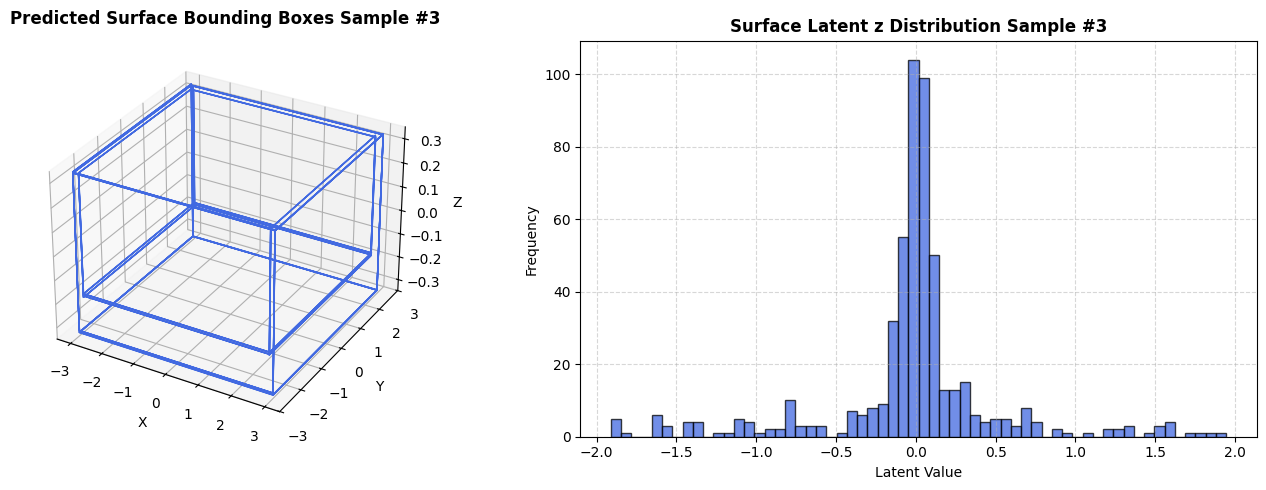

In [4]:
for i in range(batch_size):
    fig = plt.figure(figsize=(14, 5))

    # 3D Bounding Boxes
    ax1 = fig.add_subplot(121, projection='3d')
    bboxes_np = surfPos[i][~surfMask[i]].detach().cpu().numpy()
    plot_3d_bounding_boxes(bboxes_np, title=f"Predicted Surface Bounding Boxes Sample #{i}", ax=ax1)

    # Latent distribution histogram
    ax2 = fig.add_subplot(122)
    z_vals = surfZ[i][~surfMask[i]].detach().cpu().numpy().flatten()
    ax2.hist(z_vals, bins=60, color='royalblue', edgecolor='black', alpha=0.75)
    ax2.set_title(f"Surface Latent z Distribution Sample #{i}", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Latent Value")
    ax2.set_ylabel("Frequency")
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


---
### Step 2: Edge & Vertex Generation and VAE Decoding

Once the surface bounding boxes and continuous geometry are established, BrepGen synthesizes the trimming edges:
1. **Step 2-1 (Edge Position Diffusion)**:
   - Sample noise for edge bounding boxes $B^E \sim \mathcal{N}(0, I) \in \mathbb{R}^{B 	imes N_F 	imes 30 	imes 6}$.
   - Denoise using `EdgePosNet` conditioned on parent surface positions $B^F$ and latents $z^F$.
2. **Step 2-2 (Deduplication)**:
   - Filter out duplicate edge bounding boxes per face.
3. **Step 2-3 (Edge Latent & Vertex Offset Diffusion)**:
   - Denoise $18\text{-D}$ vectors using `EdgeZNet`:
     - $12\text{-D}$ edge curve continuous latent $z_E$
     - $6\text{-D}$ edge start/end endpoint vertex coordinates $v$
4. **VAE Decoding**:
   - Surface VAE decodes $z^F \in \mathbb{R}^{48} \rightarrow 32 \times 32 \times 3$ point grids for each face.
   - Edge VAE decodes $z^E \in \mathbb{R}^{12} \rightarrow 32 \times 3$ 1D curve point sequences for each edge.


In [5]:
num_edges = 30

# 2-1 & 2-2: Generate and deduplicate edge positions
edgePos, edgeM = step2_generate_edge_positions(
    deepcad_models, 
    pndm_scheduler, 
    ddpm_scheduler,
    surfPos, 
    surfZ, 
    surfMask,
    batch_size=batch_size, 
    num_surfaces=cur_num_surfaces, 
    num_edges=num_edges,
    use_cf=False, 
    bbox_threshold=0.08, 
    device=device
)
# 2-3 & VAE decode
edge_data = step2_generate_edge_latents(
    deepcad_models, 
    pndm_scheduler,
    surfPos, 
    surfZ, 
    surfMask, 
    edgePos, 
    edgeM,
    batch_size=batch_size, 
    num_surfaces=cur_num_surfaces, 
    num_edges=num_edges,
    use_cf=False, 
    device=device
)

print("Edge Latents z Shape:          ", tuple(edge_data['edge_z'].shape))
print("Decoded Surfaces (surf_ncs):   ", edge_data['surf_ncs'].shape, "(32x32 grid per face)")
print("Decoded Edge Curves (edge_ncs):", edge_data['edge_ncs'].shape, "(32 points per edge)")


Step 2-3: Edge Latent z & Vertices (PNDM): 100%|██████████| 209/209 [00:11<00:00, 18.53it/s]


Edge Latents z Shape:           (4, 60, 30, 12)
Decoded Surfaces (surf_ncs):    (4, 60, 32, 32, 3) (32x32 grid per face)
Decoded Edge Curves (edge_ncs): (4, 60, 30, 32, 3) (32 points per edge)


### Visualizing Decoded Surface Patches and Trimming Curves
Below is the point cloud geometry output directly from the VAE decoders before topological joint optimization:


In [6]:
for i in range(batch_size):
    surf_patches = edge_data['surf_ncs'][i][~surfMask[i].detach().cpu().numpy()]
    edge_curves = edge_data['edge_ncs'][i][0][:6]  # First face trimming edges
    plot_surface_patches_pointcloud(
        surf_patches, 
        edge_wcs=edge_curves,
        title=f"Decoded Surface Point Grids & Trimming Curves (Sample #{i})",
        max_patches=12,
        interactive=True,
        height=480,
        point_size=4.0
    )


---
### Step 3: Topology Recovery, Joint Optimization & B-rep Construction

The neural network outputs individual geometric patches. To turn them into a valid, watertight CAD B-rep, BrepGen performs a 4-stage post-processing pipeline:

1. **Step 3-1: Shared Vertex Detection (`detect_shared_vertex`)**:
   - Each edge predicts start and end vertex coordinates. Nearby endpoints across adjacent edges are clustered into unique topological vertices.
2. **Step 3-2: Shared Edge Detection (`detect_shared_edge`)**:
   - Adjacent faces that share the same two vertices are matched using latent cosine similarity of their edge vectors ($z_{\text{threshold}} = 0.2$), establishing the Face-Edge Adjacency matrix $A^{FE}$.
3. **Step 3-3: Joint Optimization (`joint_optimize`)**:
   - The surfaces, edges, and vertices are aligned by minimizing a topology-aware Chamfer distance (computed locally via PyTorch) between edge curves and face boundaries:
     $$\mathcal{L}_{\text{align}} = d_{\text{Chamfer}}(\text{Edge points}, \text{Surface points})$$
4. **Step 3-4: OpenCASCADE B-rep Construction (`construct_brep`)**:
   - Parametric B-spline surfaces ($32 \times 32$ points) and B-spline curves ($32$ points) are fitted using OpenCASCADE `GeomAPI_PointsToBSplineSurface` and `GeomAPI_PointsToBSpline`.
   - Curve loops are assembled into wires to trim face boundaries (`BRepBuilderAPI_MakeFace`).
   - Trimmed faces are sewn together (`BRepBuilderAPI_Sewing`) to form a closed, watertight CAD solid (`BRepBuilderAPI_MakeSolid`).


In [12]:
for i in range(batch_size): 
    solid, debug_info = step3_reconstruct_cad_solid(
        sample_idx=i,
        surfPos=surfPos,
        surfMask=surfMask,
        surfZ=surfZ,
        edge_data=edge_data,
        surf_vae=deepcad_models['surf_vae'],
        edge_vae=deepcad_models['edge_vae'],
        z_threshold=0.2,
        use_local_cd=True,
        device=device
    )

    if solid is not None:
        print(f"Successfully reconstructed CAD B-rep Solid for Sample #{i}!")
        if 'unique_vertices' in debug_info:
            print(f"  Topological Vertices Sample #{i}: {len(debug_info['unique_vertices'])}")
        mesh, bd_shape = solid_to_mesh(solid, tolerance=0.005)
        plot_surface_patches_pointcloud(debug_info['surf_wcs'], edge_wcs=debug_info['edge_wcs'])
        render_3d_mesh_jupyter(mesh, title="Generated DeepCAD 3D B-rep Solid", interactive=True)

    else:
        print(f"Solid construction FAILED for sample #{i}.\n")


[PASS]
[PASS]
[FAILED]
Sample #0: Vertex detection failed ()
Solid construction FAILED for sample #0.

[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
Post-process: F-18 E-48 V-32
Joint Optimization...
Building the B-rep...
Successfully reconstructed CAD B-rep Solid for Sample #1!
  Topological Vertices Sample #1: 32


[PASS]
[FAILED]
Sample #2: Vertex detection failed ()
Solid construction FAILED for sample #2.

[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
[PASS]
Post-process: F-11 E-24 V-16
Joint Optimization...
Building the B-rep...
Successfully reconstructed CAD B-rep Solid for Sample #3!
  Topological Vertices Sample #3: 16


---
### Step 4: Visualizing the Generated 3D CAD Solids

We use the exact same interactive 3D visualization as in the DeepCAD notebook:
- Tessellates the B-rep solid into a triangular mesh with deflection tolerance $\epsilon = 0.005$
- Renders an interactive Three.js 3D viewer directly inside Jupyter with orbit, zoom, and pan controls
- Displays watertightness, vertex count, and face count statistics
- Falls back to a Matplotlib 3D projection if interactive rendering is disabled


---
## Generating ABC Dataset Models

The **ABC Dataset** is a large-scale collection of 1 million mechanical CAD models.
Unlike DeepCAD models, ABC models frequently feature complex fillets, bevels, freeform surfaces, and intricate multi-loop faces.

To accommodate this higher geometric complexity, BrepGen uses expanded parameters:
- `num_surfaces`: $50$
- `num_edges`: $40$
- `use_cf`: `False` (Unconditional)


In [8]:
abc_dir = os.path.join(CHECKPOINT_BASE_DIR, 'abc') if os.path.exists(os.path.join(CHECKPOINT_BASE_DIR, 'abc')) else CHECKPOINT_BASE_DIR
abc_weights = {
    'surfpos_weight': os.path.join(abc_dir, 'abc_ldm_surfpos.pt'),
    'surfz_weight':   os.path.join(abc_dir, 'abc_ldm_surfz.pt'),
    'edgepos_weight': os.path.join(abc_dir, 'abc_ldm_edgepos.pt'),
    'edgez_weight':   os.path.join(abc_dir, 'abc_ldm_edgez.pt'),
    'surfvae_weight': os.path.join(abc_dir, 'abc_vae_surf.pt'),
    'edgevae_weight': os.path.join(abc_dir, 'abc_vae_edge.pt'),
}
abc_ready = all(os.path.exists(p) for p in abc_weights.values())
if not abc_ready:
    raise ValueError(f"Could not find checkpoints at {CHECKPOINT_BASE_DIR}")

abc_models = load_brepgen_models(abc_weights, use_cf=False, device=device)
print("Successfully loaded all ABC dataset models onto", device)


Successfully loaded all ABC dataset models onto cuda


In [9]:
solid_abc, mesh_abc, debug_abc = generate_brep_cad_model(
    abc_models, 
    (pndm_scheduler, ddpm_scheduler),
    mode="abc", 
    seed=107, 
    num_surfaces=50, 
    num_edges=40,
    interactive=True, 
    device=device
)

Step 2-3: Edge Latent z & Vertices (PNDM): 100%|██████████| 209/209 [00:11<00:00, 17.70it/s]


[PASS]
[PASS]
[FAILED]
Sample #0: Vertex detection failed ()


---
## Generating Furniture Models (Class-Conditioned)

The Furniture dataset contains 3D CAD furniture designs categorized into 10 distinct classes:
- `bathtub` (1)
- `bed` (2)
- `bench` (3)
- `bookshelf` (4)
- `cabinet` (5)
- `chair` (6)
- `couch` (7)
- `lamp` (8)
- `sofa` (9)
- `table` (10)

however the authors did not provide the checkpoints for the checkpoints for the pretrained conditioned models.


In [ ]:
furniture_dir = os.path.join(CHECKPOINT_BASE_DIR, 'deepcad') if os.path.exists(os.path.join(CHECKPOINT_BASE_DIR, 'deepcad')) else CHECKPOINT_BASE_DIR
furniture_weights = {
    'surfpos_weight': os.path.join(deepcad_dir, 'deepcad_ldm_surfpos.pt'),
    'surfz_weight':   os.path.join(deepcad_dir, 'deepcad_ldm_surfz.pt'),
    'edgepos_weight': os.path.join(deepcad_dir, 'deepcad_ldm_edgepos.pt'),
    'edgez_weight':   os.path.join(deepcad_dir, 'deepcad_ldm_edgez.pt'),
    'surfvae_weight': os.path.join(deepcad_dir, 'deepcad_vae_surf.pt'),
    'edgevae_weight': os.path.join(deepcad_dir, 'deepcad_vae_edge.pt'),
}
furniture_ready = all(os.path.exists(p) for p in furniture_weights.values())
if not furniture_ready:
    raise ValueError(f"Could not find checkpoints at {CHECKPOINT_BASE_DIR}")

furniture_models = load_brepgen_models(furniture_weights, use_cf=True, device=device)
print("Successfully loaded Furniture class-conditioned models onto", device)


In [ ]:
selected_class = 'chair'
print(f"Generating class-conditioned CAD model for category: '{selected_class}' (Class ID: {text2int[selected_class]})...")

if furniture_ready:
    solid_chair, mesh_chair, debug_chair = generate_brep_cad_model(
        furniture_models, (pndm_scheduler, ddpm_scheduler),
        mode="furniture", class_label=selected_class, seed=42,
        num_surfaces=60, num_edges=40, use_cf=True, w=0.6,
        interactive=True, device=device
    )
else:
    demo_chair = create_demo_cad_solid()
    mesh_chair, _ = solid_to_mesh(demo_chair)
    render_3d_mesh_jupyter(mesh_chair, title=f"Furniture Model - '{selected_class}' (Demo Verification)", interactive=True)


Generating class-conditioned CAD model for category: 'chair' (Class ID: 6)...


NameError: name 'create_demo_cad_solid' is not defined

### Exploring Different Furniture Categories

You can easily generate other categories by passing different class names into the generation function.
Let's see an example with `table`:


In [ ]:
selected_class_2 = 'table'
print(f"Generating class-conditioned CAD model for category: '{selected_class_2}'...")

if furniture_ready:
    solid_table, mesh_table, debug_table = generate_brep_cad_model(
        furniture_models, (pndm_scheduler, ddpm_scheduler),
        mode="furniture", class_label=selected_class_2, seed=123,
        num_surfaces=60, num_edges=40, use_cf=True, w=0.6,
        interactive=True, device=device
    )
else:
    demo_table = create_demo_cad_solid()
    mesh_table, _ = solid_to_mesh(demo_table)
    render_3d_mesh_jupyter(mesh_table, title=f"Furniture Model - '{selected_class_2}' (Demo Verification)", interactive=True)


---
## Unified Generator Function

Just like `generate_random_cad_model` in the DeepCAD tutorial, here is a single unified function to generate any B-rep CAD solid by specifying dataset mode, category, seed, and export preferences.
Both STEP and STL formats are supported for direct export into SolidWorks, FreeCAD, Fusion 360, or Blender.


In [ ]:
def generate_random_brep_model(
    mode="deepcad",
    class_label=None,
    seed=None,
    stl_file_name=None,
    step_file_name=None,
    interactive=True
):
    """
    Unified end-to-end generator for BrepGen CAD models.
    
    Args:
        mode (str): 'deepcad', 'abc', or 'furniture'
        class_label (str): Class category for furniture (e.g. 'chair', 'table', 'bed')
        seed (int): Optional random seed for reproducible generations
        stl_file_name (str): Optional path to export STL file
        step_file_name (str): Optional path to export standard STEP file
        interactive (bool): Render Three.js 3D viewer inside Jupyter
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    # Select appropriate loaded model dictionary
    model_map = {
        'deepcad': deepcad_models if deepcad_ready else None,
        'abc': abc_models if abc_ready else None,
        'furniture': furniture_models if furniture_ready else None,
    }
    active_models = model_map.get(mode)

    if active_models is not None:
        solid, mesh, _ = generate_brep_cad_model(
            active_models, (pndm_scheduler, ddpm_scheduler),
            mode=mode, class_label=class_label, seed=seed,
            interactive=False, device=device
        )
    else:
        print(f"Running in demonstration mode for '{mode}' (Checkpoints not loaded).")
        solid = create_demo_cad_solid()

    if solid is not None:
        mesh, bd_shape = solid_to_mesh(
            solid,
            tolerance=0.005,
            stl_file_name=stl_file_name,
            step_file_name=step_file_name
        )
        title = f"BrepGen CAD Solid [{mode.upper()}]"
        if class_label:
            title += f" ({class_label})"
        if seed is not None:
            title += f" [Seed: {seed}]"
        render_3d_mesh_jupyter(mesh, title=title, interactive=interactive)
        return solid, mesh, bd_shape
    else:
        print("Failed to construct 3D CAD model.")
        return None, None, None

# Test the unified function with fixed seed
solid_out, mesh_out, shape_out = generate_random_brep_model(
    mode="deepcad",
    seed=400,
    stl_file_name="sample_deepcad.stl",
    step_file_name="sample_deepcad.step",
    interactive=True
)


---
## Summary and Key Takeaways

1. **Direct Boundary Representation (B-rep)**:
   - DeepCAD generates sequential extrusion commands that require boolean replay.
   - BrepGen directly predicts parametric surfaces, trimming curves, and topological vertices in a unified top-down diffusion process.
2. **Top-Down Diffusion Hierarchy**:
   - Level 1: Surface bounding boxes $B^F$ and deduplication.
   - Level 2: Surface continuous geometry latents $z^F$ (48-D).
   - Level 3: Edge bounding boxes $B^E$ and deduplication.
   - Level 4: Edge continuous latents $z^E$ (12-D) and endpoint vertex coordinates $v$ (6-D).
3. **Topology-Aware Post-Processing**:
   - Endpoint clustering for shared vertex detection.
   - Latent cosine distance for shared edge matching.
   - Joint optimization aligning face boundaries and edge curves with local Chamfer distance.
   - OpenCASCADE B-spline fitting, wire construction, and solid sewing into watertight STEP/STL CAD geometry.
4. **Multi-Dataset and Conditional Versatility**:
   - Supports mechanical CAD models (DeepCAD, ABC) as well as complex class-conditioned shapes (Furniture) via Classifier-Free Guidance.
